In [63]:
import tensorflow as tf
from tensorflow import keras

import sklearn
import numpy as np
import pandas as pd
import sklearn.datasets
import sklearn.preprocessing
import functions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from tslearn.metrics import dtw
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
import datetime
from collections import Counter
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import CubicSpline, interp1d, PchipInterpolator
from imblearn.over_sampling import SMOTE

In [64]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]
        )
        print("GPU memory limit set to 4096MB")
    except RuntimeError as e:
        print(e)

GPU memory limit set to 4096MB


# 1. Preprocessing:

SGCC dataset of timeseries of ~ 40k users electrical load usage within the same building
- Each timeseries contains 1034 observed loads, representing 2.833 year's worth of daily load measurements 
- Heavy class imbalance (~8.5% anomalous to ~91.5% normal users)
  

**Preprocessing:**
- Exclude poor quality data (NaN (missing value) at least 40% of timeseries / NaN entries at each end of the timeseries) 
- Missing data imputation through cubic spline interpolation on 'fuller' timeseries
- Min-max normalization applied on dataset to scale data

In [65]:
X_full, y_full = functions.load_SGCC_dataset()
X_full

,2014-01-01,2014-01-02,2014-01-03,2014-01-04,2014-01-05,2014-01-06,2014-01-07,2014-01-08,2014-01-09,2014-01-10,...,2016-10-22,2016-10-23,2016-10-24,2016-10-25,2016-10-26,2016-10-27,2016-10-28,2016-10-29,2016-10-30,2016-10-31
0,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.02,0.83,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25
1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,17.83,23.91,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14
2,0.0,0.0,0.00,0.0,0.0,4.98,9.87,11.29,13.44,11.34,...,NaN,NaN,NaN,1.43,2.22,2.41,3.48,2.89,1.88,1.16
3,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,19.96,19.50,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67
4,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,2.14,2.59,0.61,1.33,0.55,1.62,1.53,2.10,1.16,2.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.51,3.92,3.79,6.02,2.52,8.60,4.23,3.54,3.26,4.49
42368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.07,9.86,10.65,9.95,10.83,11.85,11.46,8.98,9.95,7.52
42369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.59,0.95,0.39,0.86,0.60,0.82,0.65,0.53,0.77,0.56
42370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.27,3.10,2.75,3.01,2.99,2.83,2.54,3.40,3.59,2.54


In [66]:
# 0 is classified as normal, 1 is classified as theft
y_full.value_counts()

FLAG
0    38757
1     3615
Name: count, dtype: int64

In [67]:
def visualize(loads:pd.DataFrame):
    plt.figure(figsize=(20,5))
    plt.plot(range(len(loads)), loads.to_numpy(), color='blue')
    plt.xlim(0, len(loads) - 1)
    plt.show()

In [68]:
test_row1 = X_full.iloc[123, :].copy()
test_row2 = X_full.iloc[10000, :].copy()
test_row3 = X_full.iloc[-1, :].copy()
test_row4 = X_full.iloc[2,:].copy()

y1 = y_full.iloc[123].copy()
y2 = y_full.iloc[10000].copy()
y3 = y_full.iloc[-1].copy()

def cubic_spline_interpolate(series:pd.DataFrame):
    # We dont interpolate poor quality timeseries. Interpolating poor quality data result in synthetic generation of poor data, which causes overfitting
    if (series.isna().sum()/len(series) > 0.50) or series.iloc[:300].isna().all() or series.iloc[-300:].isna().all():
        return series
    
    mask = ~series.isna()
    value_known = series[mask].values
    index_known = series.index[mask]
    
    cs = CubicSpline(index_known, value_known, extrapolate=False)
    y_interpolate = np.clip(cs(series.index), 0, a_max=None)
    
    return pd.Series(y_interpolate, index=series.index)

def pchip_cubic_spline_interpolate(series:pd.DataFrame):
    # We dont interpolate poor quality timeseries. Interpolating poor quality data result in synthetic generation of poor data, which causes overfitting
    if (series.isna().sum()/len(series) > 0.50) or series.iloc[:100].isna().all() or series.iloc[-100:].isna().all():
        return series
    
    mask = ~series.isna()
    value_known = series[mask].values
    index_known = series.index[mask]
    
    pchip_cs = PchipInterpolator(index_known, value_known)
    y_interpolate = np.clip(pchip_cs(series.index), 0, a_max=None)
    
    return pd.Series(y_interpolate, index=series.index)


test_row1_interpolated = cubic_spline_interpolate(test_row1)

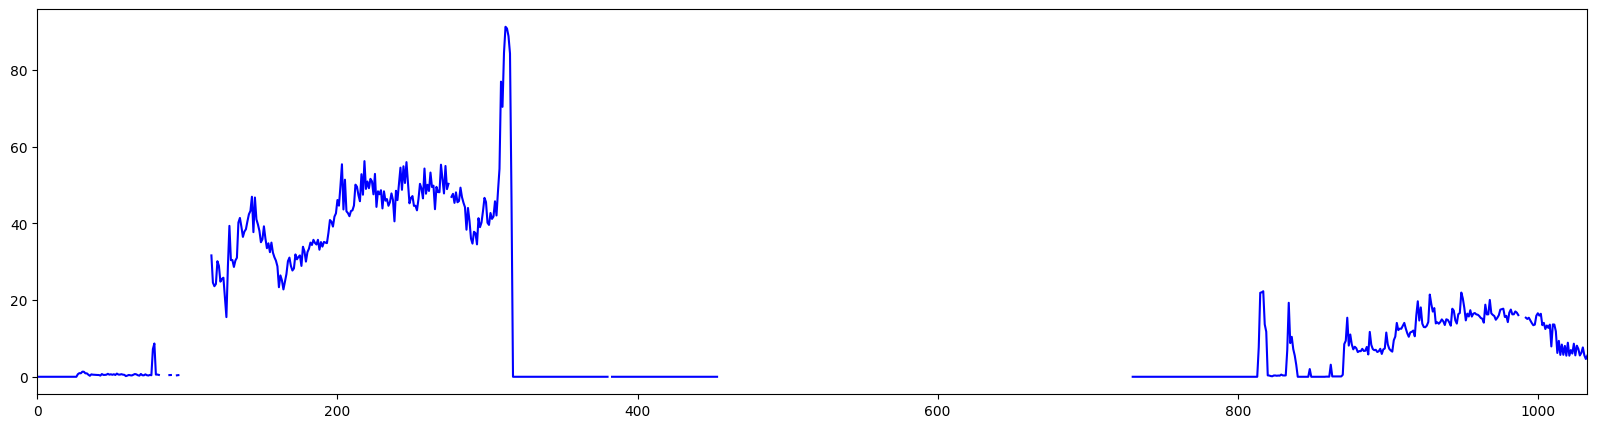

In [69]:
visualize(test_row1)

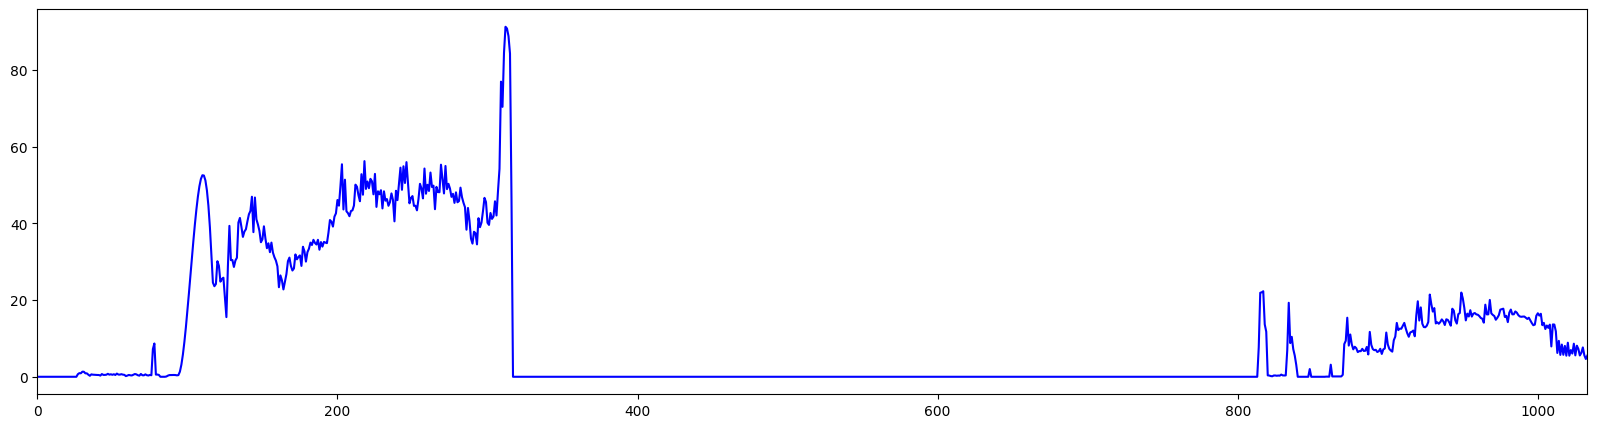

In [70]:
visualize(test_row1_interpolated)

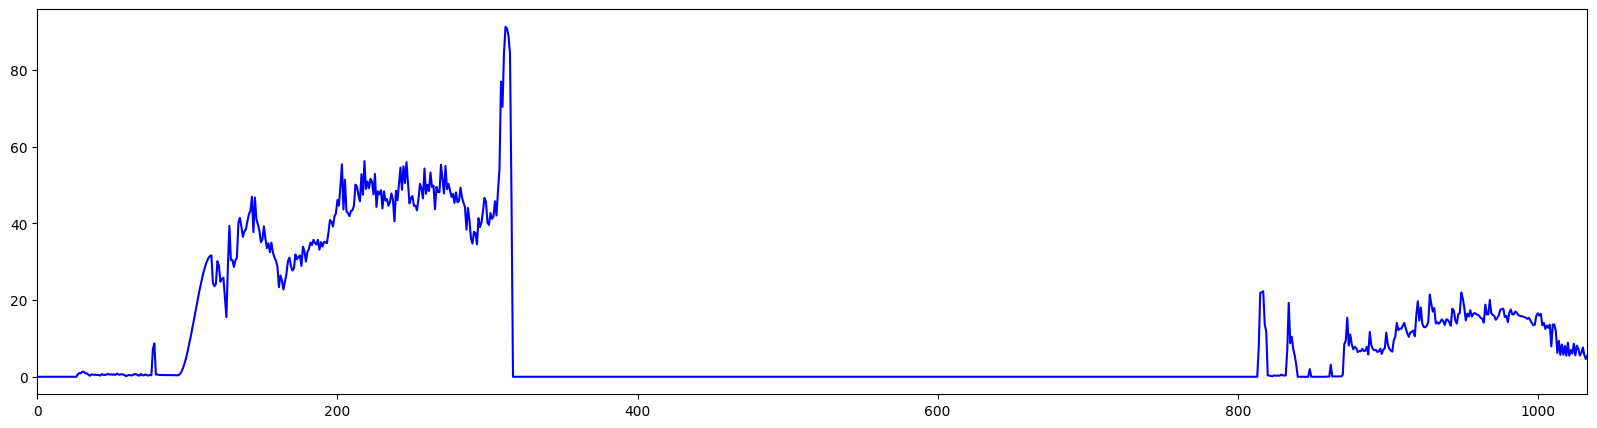

In [71]:
visualize(pchip_cubic_spline_interpolate(test_row1))

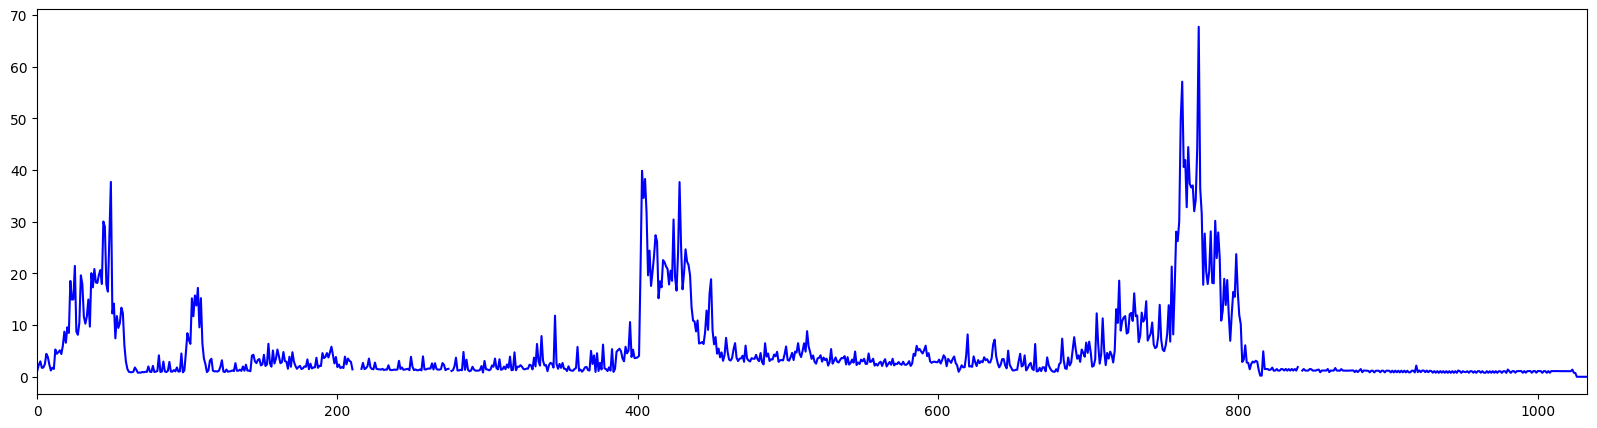

In [72]:
visualize(test_row2)

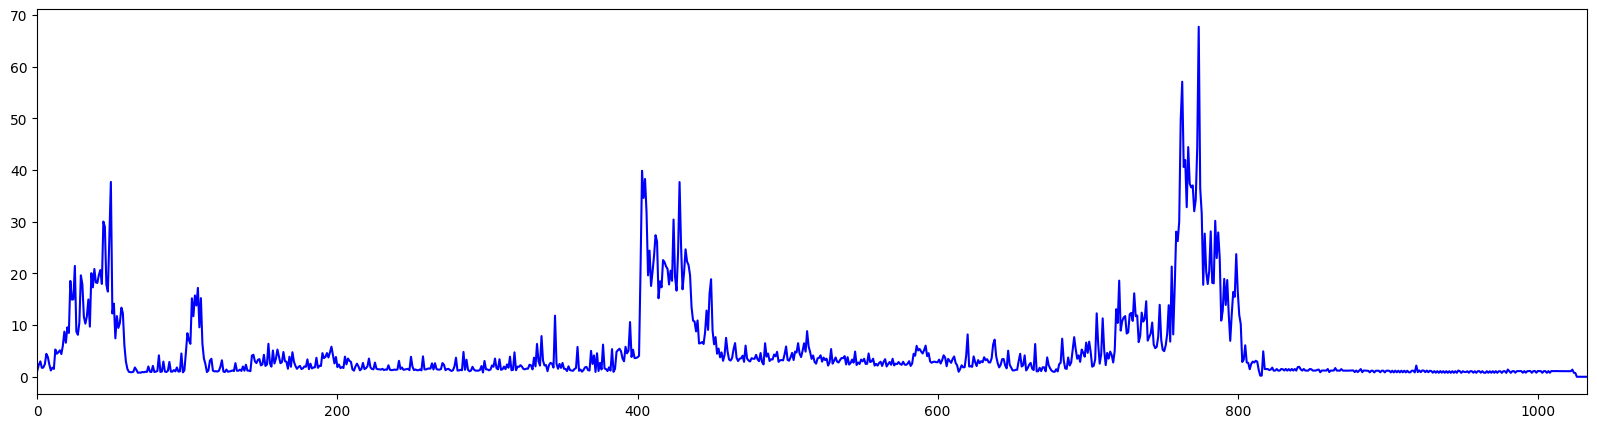

In [73]:
visualize(cubic_spline_interpolate(test_row2))

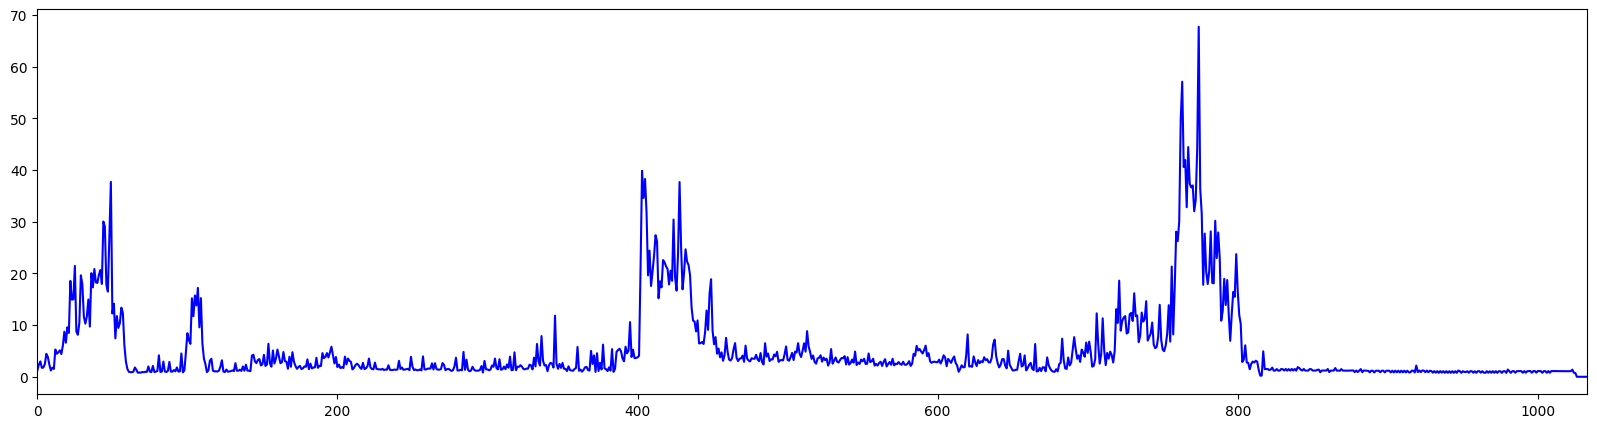

In [74]:
visualize(pchip_cubic_spline_interpolate(test_row2))

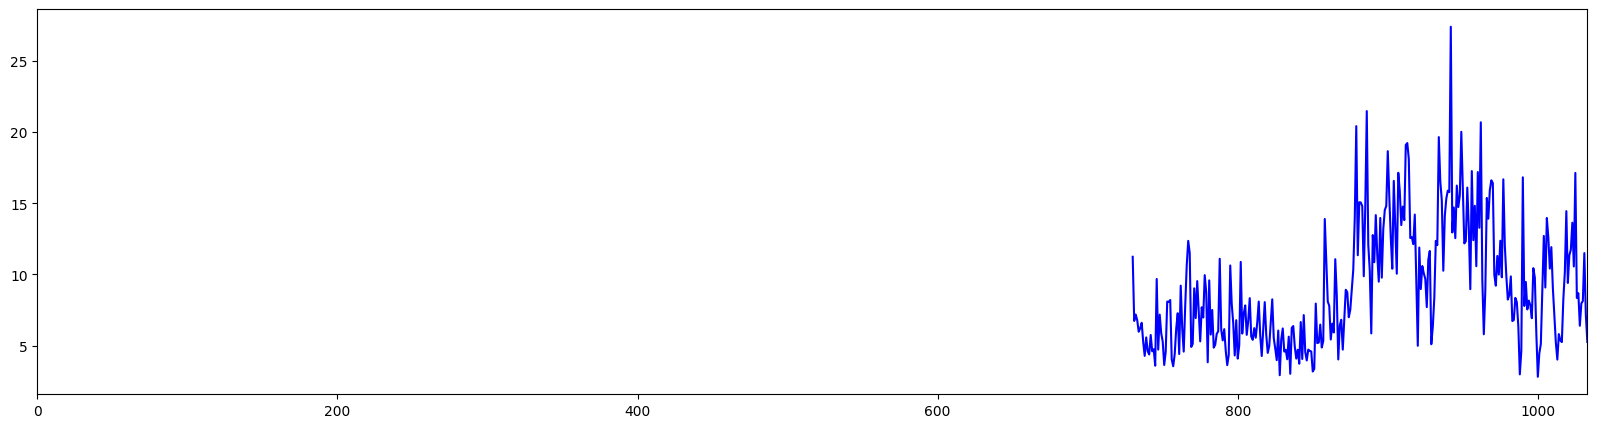

In [75]:
visualize(test_row3)

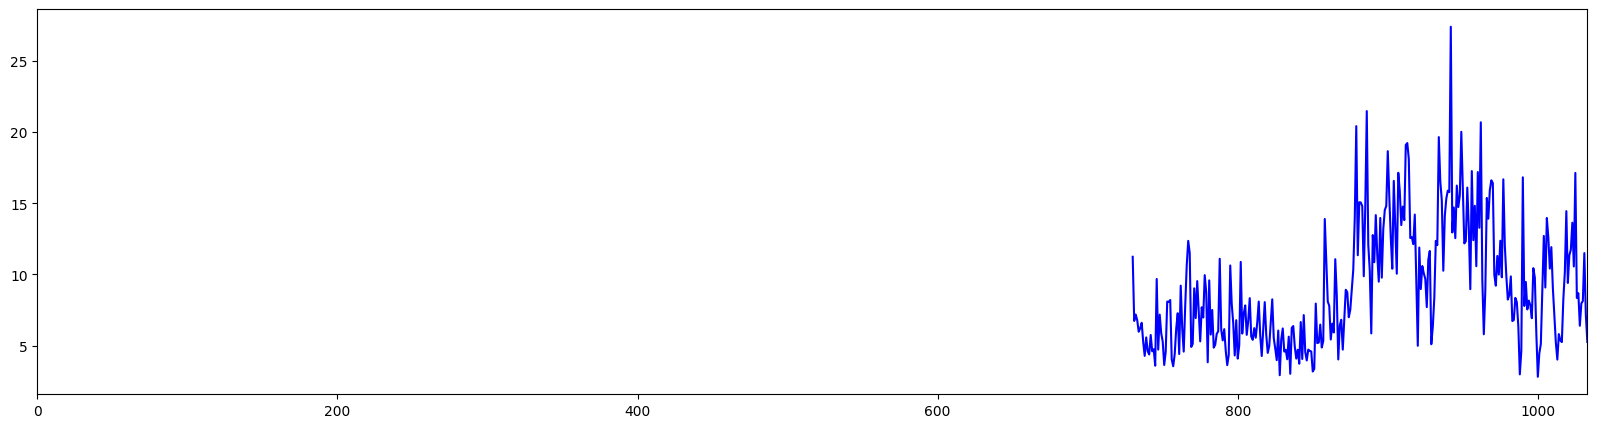

In [76]:
visualize(cubic_spline_interpolate(test_row3))

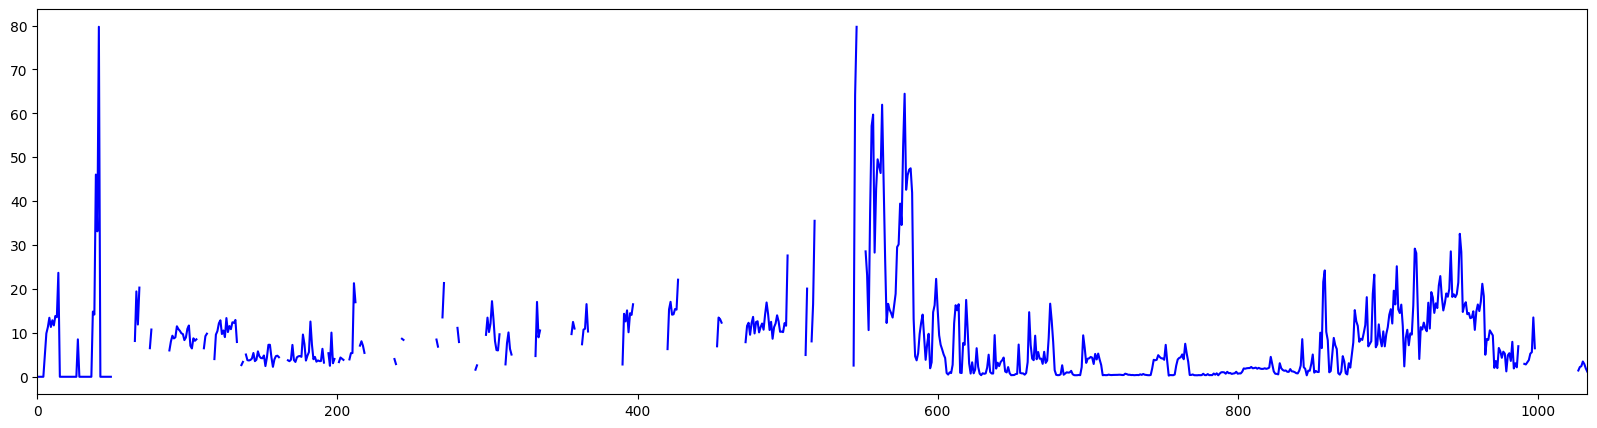

In [77]:
visualize(test_row4)

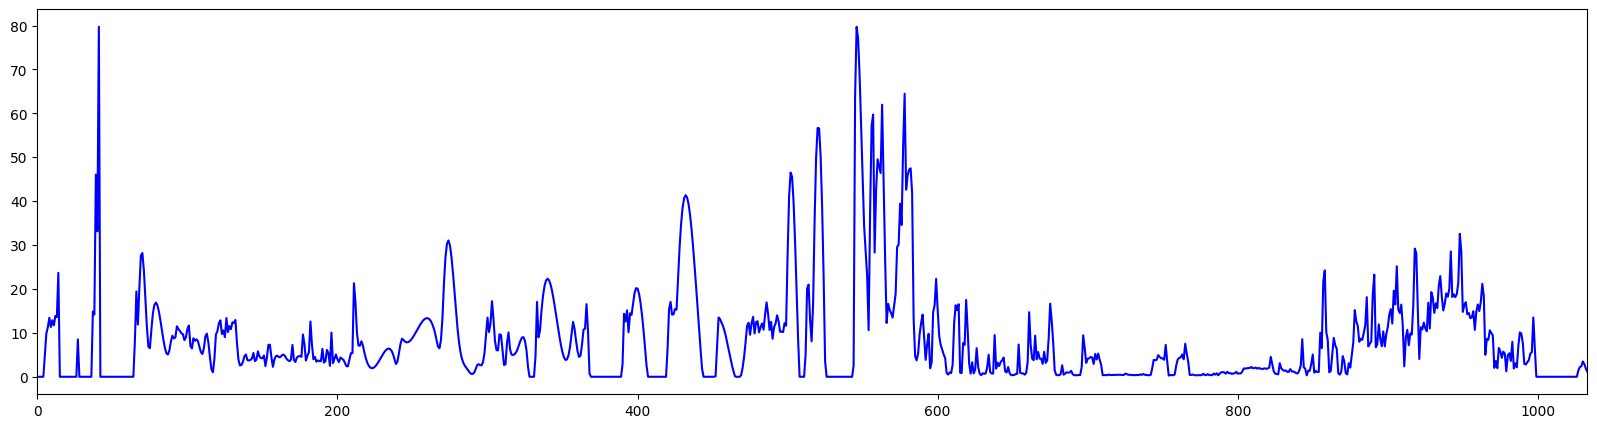

In [78]:
visualize(cubic_spline_interpolate(test_row4))

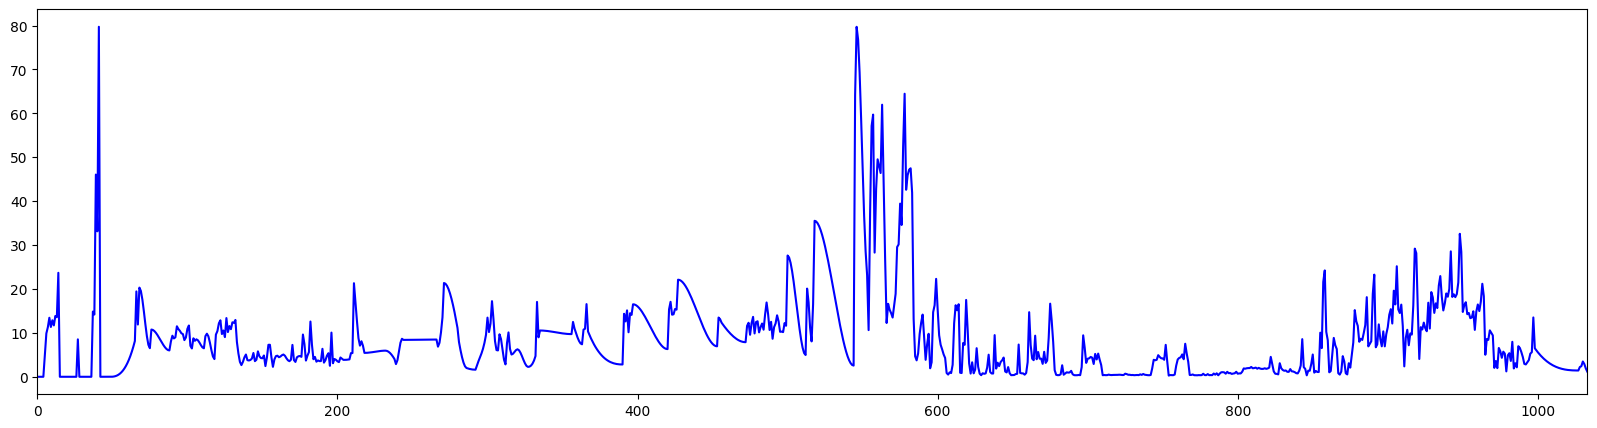

In [79]:
visualize(pchip_cubic_spline_interpolate(test_row4))

**PCHIP vs Cubic Spline**
- Cubic Spline exhibit sharper imputations, which may overshoot the actual load pattern
- PCHIP takes into account the the shapes (local mins / maxes), hence does not tend to overshoot
  - Can be considered after the fact



In [80]:
X_full_interpolated = X_full.copy().apply(cubic_spline_interpolate, axis=1)
X_interpolated_cleaned = X_full_interpolated.dropna(axis=0)
X_full_pchip_interpolated = X_full.copy().apply(pchip_cubic_spline_interpolate, axis=1)
X_pchip_interpolated_cleaned = X_full_interpolated.dropna(axis=0)

In [81]:
y_interpolated_cleaned = y_full.loc[X_interpolated_cleaned.index]
y_interpolated_cleaned

0        1
1        1
2        1
3        1
6        1
        ..
25864    1
25866    1
25867    1
25868    1
25869    1
Name: FLAG, Length: 24204, dtype: int64

In [82]:
# Normalization:

def normalize(dataset:pd.DataFrame):
    scaler = MinMaxScaler()
    return pd.DataFrame(scaler.fit_transform(dataset.T).T, columns=dataset.columns, index=dataset.index)

In [83]:
X_interpolated_normalized = normalize(X_interpolated_cleaned)
X_pchip_interpolated_normalized = normalize(X_pchip_interpolated_cleaned)

In [84]:
X_interpolated_cleaned

,2014-01-01,2014-01-02,2014-01-03,2014-01-04,2014-01-05,2014-01-06,2014-01-07,2014-01-08,2014-01-09,2014-01-10,...,2016-10-22,2016-10-23,2016-10-24,2016-10-25,2016-10-26,2016-10-27,2016-10-28,2016-10-29,2016-10-30,2016-10-31
0,0.0,0.0,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.02,0.83,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25
1,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,17.83,23.91,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14
2,0.0,0.0,0.00,0.00,0.00,4.98,9.87,11.29,13.44,11.34,...,0.00,0.00,0.00,1.43,2.22,2.41,3.48,2.89,1.88,1.16
3,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,19.96,19.50,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67
6,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,14.57,14.51,16.51,15.64,19.10,17.06,16.64,14.29,14.19,17.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25864,1020.8,1097.4,1377.40,1408.80,1414.80,1387.40,1444.60,1325.00,1461.60,1253.20,...,305.80,121.80,507.00,642.00,348.00,366.80,748.80,673.40,140.40,376.00
25866,1278.3,873.0,824.10,950.10,637.80,261.90,375.90,230.40,221.70,246.90,...,582.00,835.20,644.70,603.60,660.30,612.00,929.70,843.60,801.60,691.50
25867,1445.7,1348.2,1281.90,1276.35,1219.95,1289.85,1298.55,1326.15,1410.60,1376.70,...,980.10,1036.50,838.05,836.25,1042.05,1010.10,1051.50,879.75,807.90,898.20
25868,2401.0,2500.0,2674.00,2432.00,2231.00,1942.00,2752.00,1244.00,2069.00,2360.00,...,2080.00,2820.00,1872.00,1980.00,1500.00,1732.00,2000.00,1888.00,2548.00,2440.00


In [85]:
test1 = X_full.loc[0,:]
test2 = X_full.loc[12121,:]
test3 = X_full.loc[24451,:]

test1_interpolated = X_interpolated_cleaned.loc[0,:]
test2_interpolated = X_interpolated_cleaned.loc[12121,:]
test3_interpolated = X_interpolated_cleaned.loc[24451,:]

test1_pchip = X_pchip_interpolated_cleaned.loc[0,:]
test2_pchip = X_pchip_interpolated_cleaned.loc[12121,:]
test3_pchip = X_pchip_interpolated_cleaned.loc[24451,:]

test1_normalized = X_interpolated_normalized.loc[0,:]
test2_normalized = X_interpolated_normalized.loc[12121,:]
test3_normalized = X_interpolated_normalized.loc[24451,:]

test1_pchip_normalized = X_pchip_interpolated_normalized.loc[0,:]
test2_pchip_normalized = X_pchip_interpolated_normalized.loc[12121,:]
test3_pchip_normalized = X_pchip_interpolated_normalized.loc[24451,:]

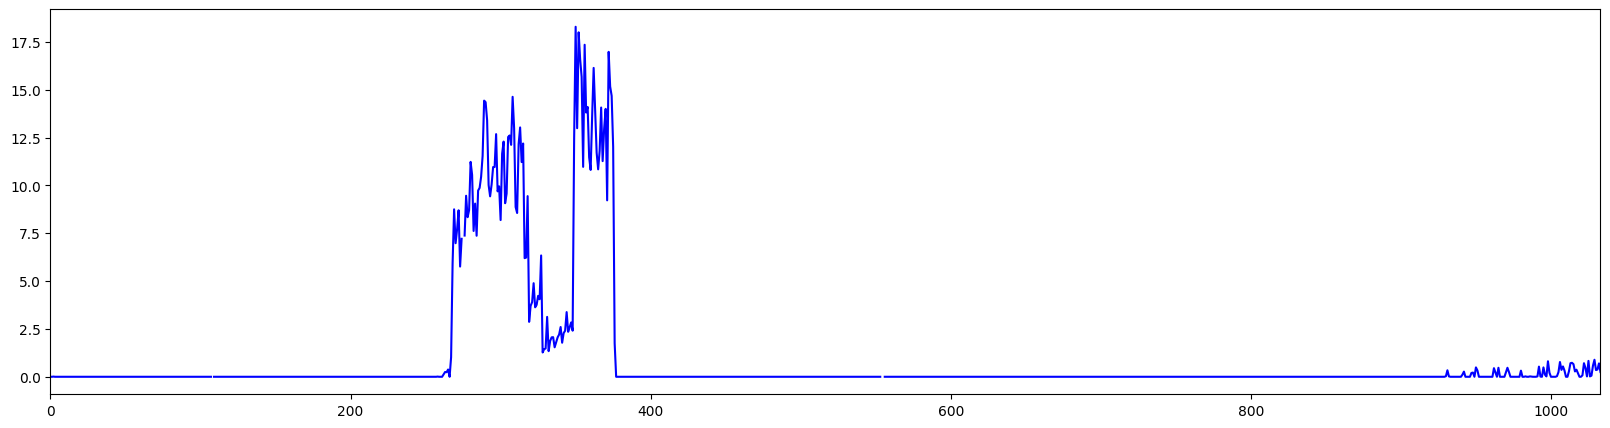

In [86]:
visualize(test1)

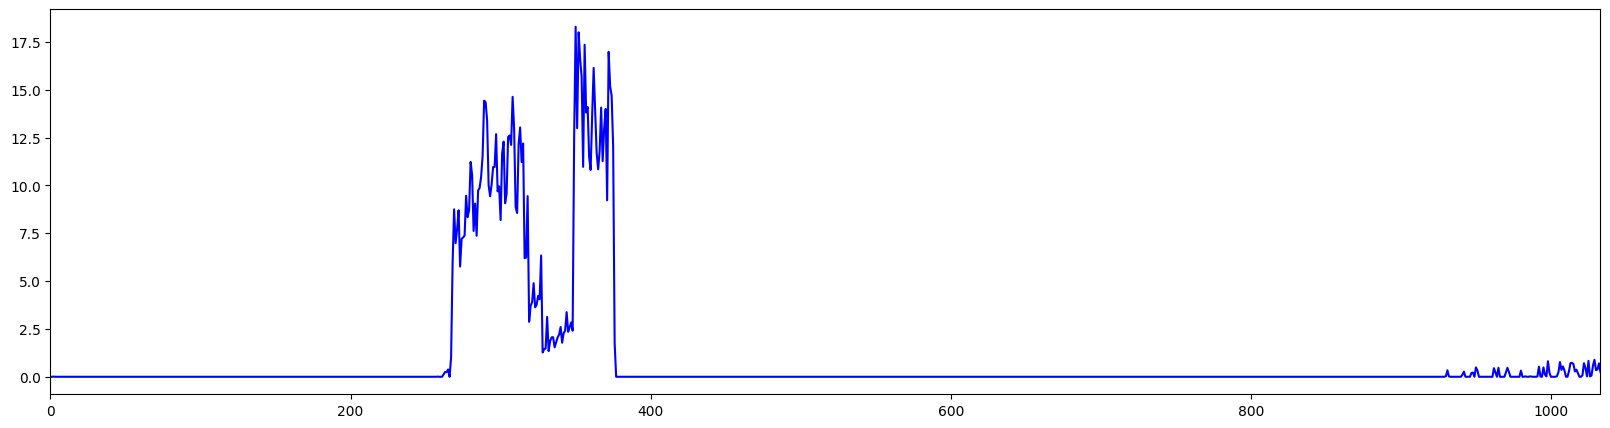

In [87]:
visualize(test1_interpolated)

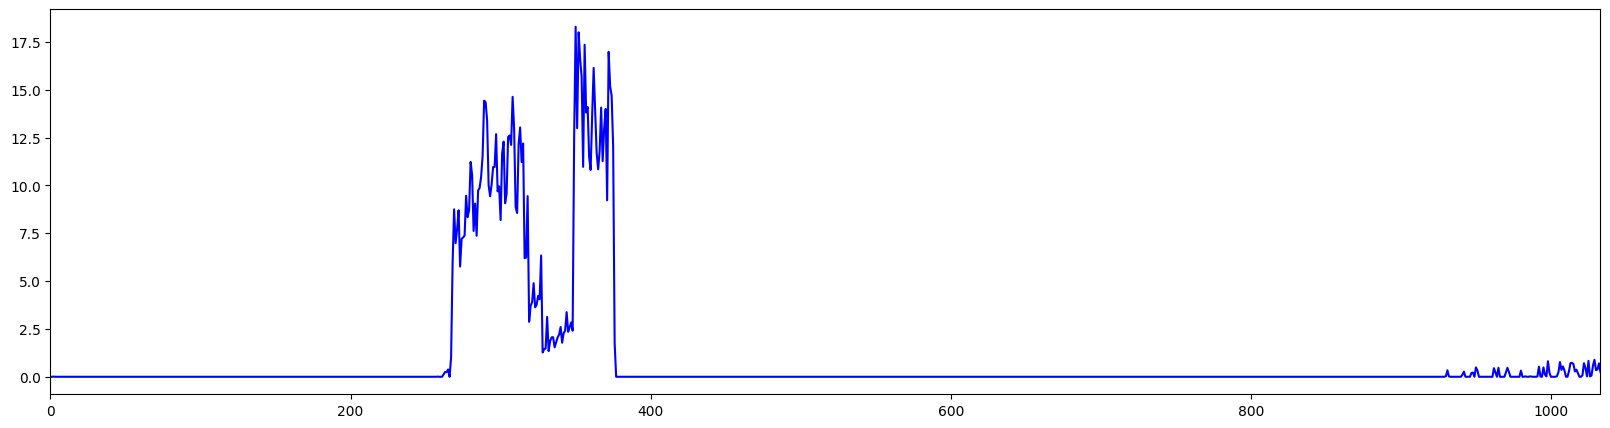

In [88]:
visualize(test1_pchip)

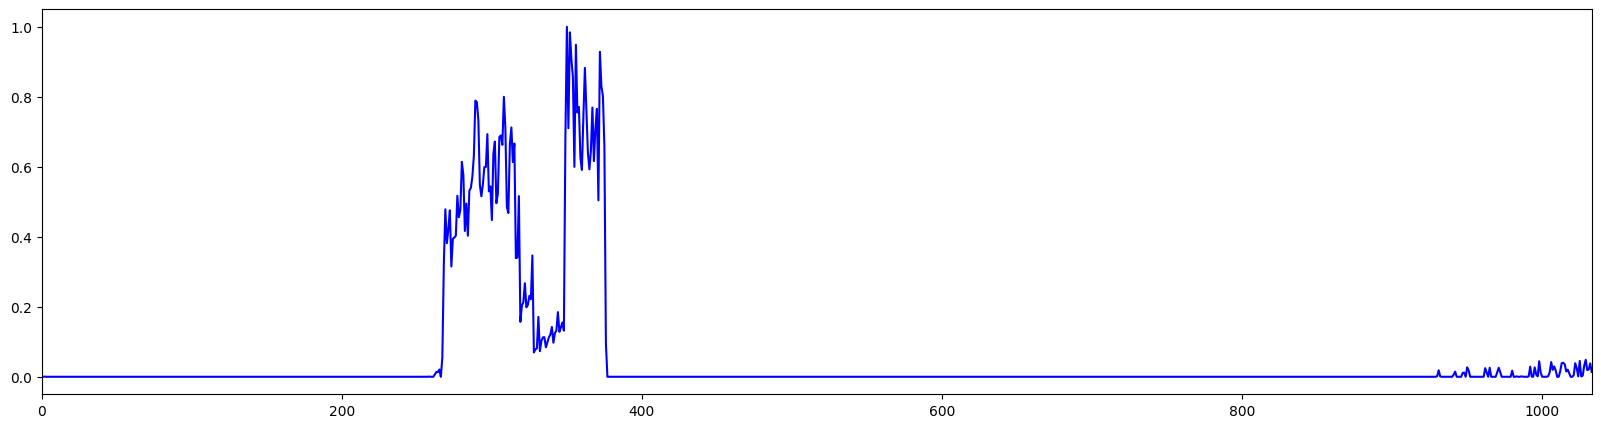

In [89]:
visualize(test1_pchip_normalized)

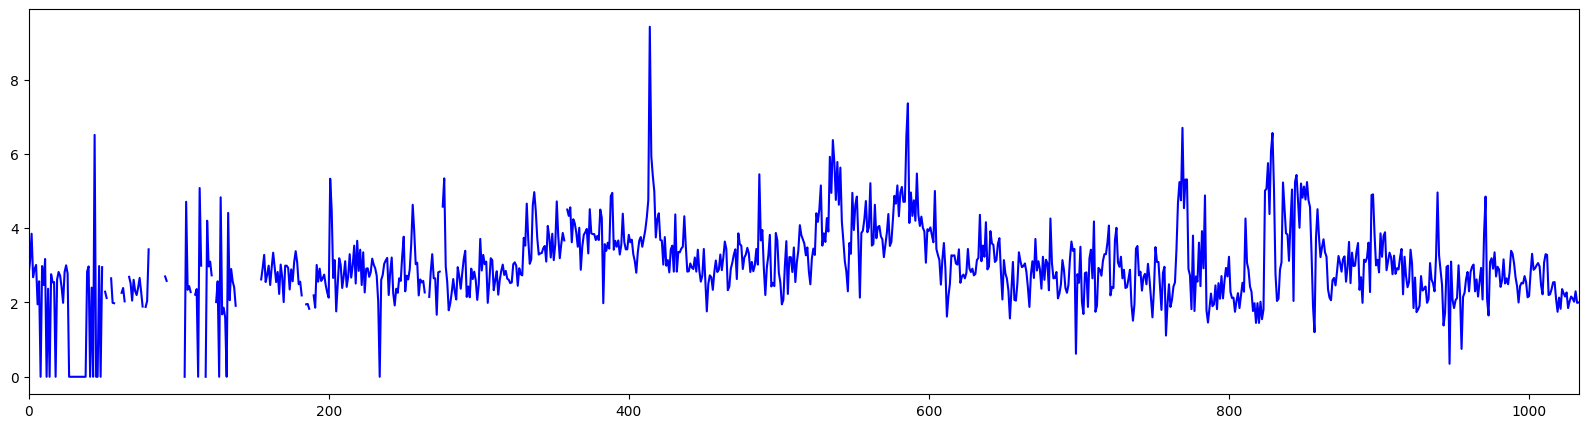

In [90]:
visualize(test2)

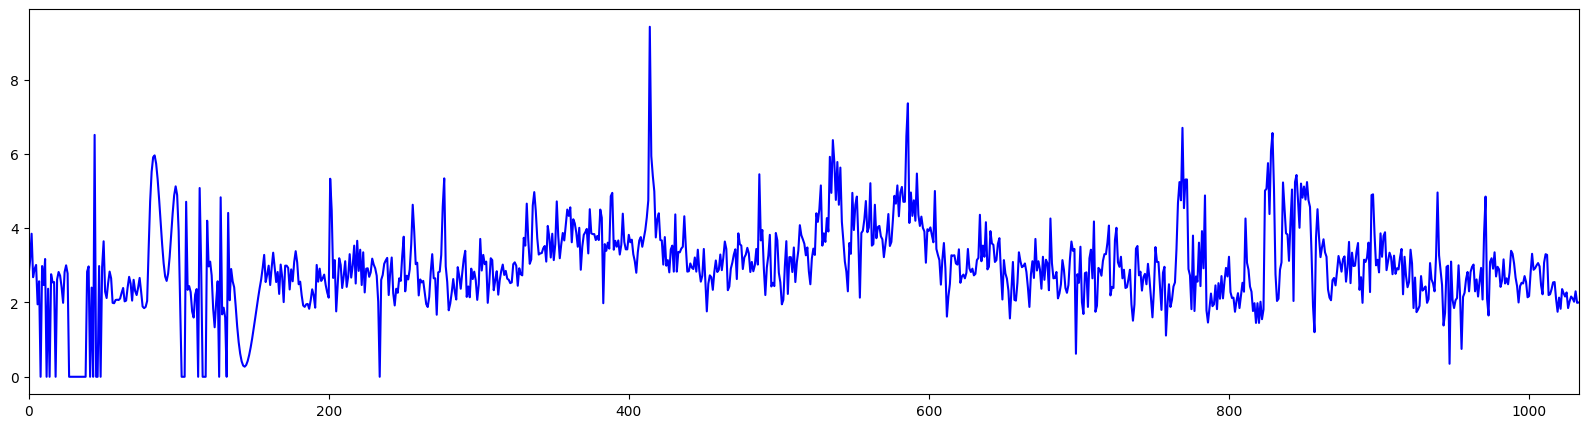

In [91]:
visualize(test2_interpolated)

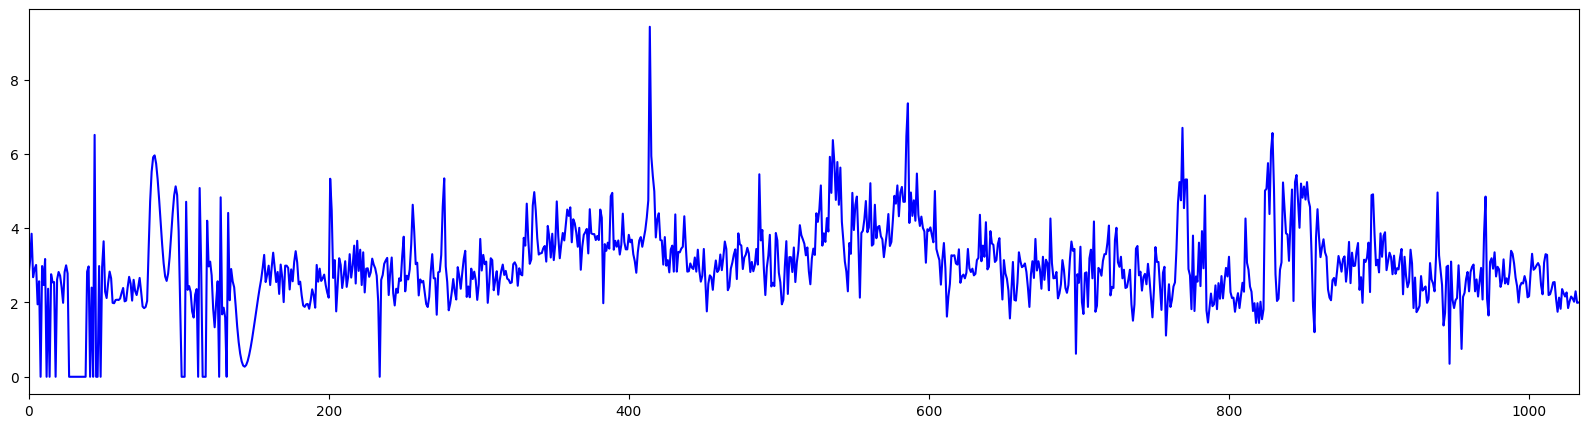

In [92]:
visualize(test2_pchip)

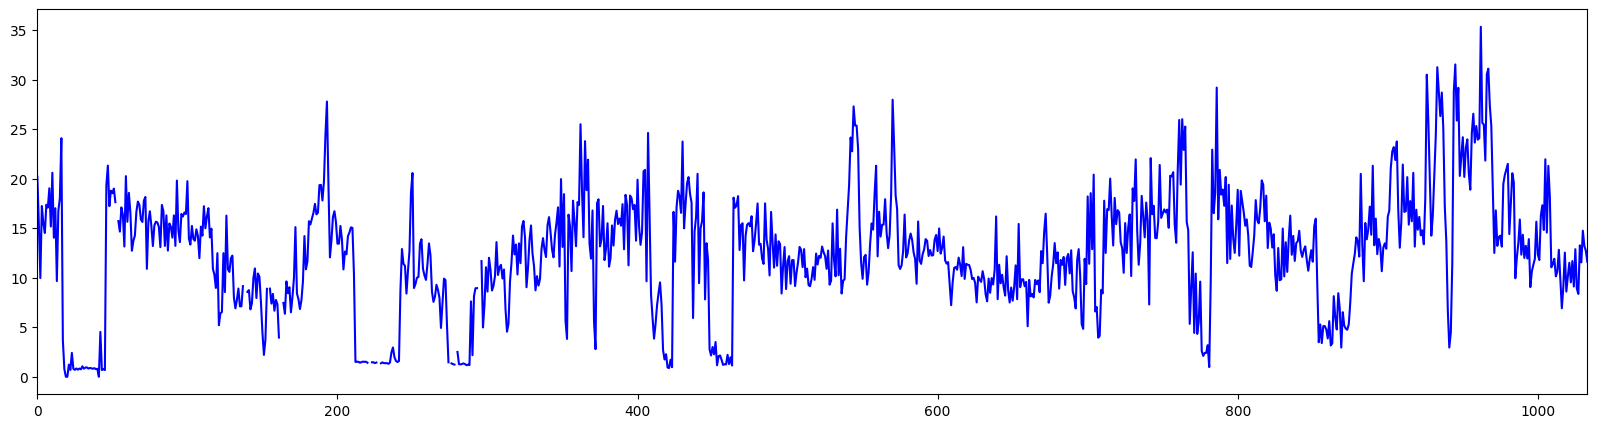

In [93]:
visualize(test3)

In [94]:
X_interpolated_cleaned.shape

(24204, 1034)

In [95]:
X_full.shape

(42372, 1034)

In [96]:
y_full.value_counts()

FLAG
0    38757
1     3615
Name: count, dtype: int64

In [97]:
y_interpolated_cleaned.value_counts()

FLAG
0    22359
1     1845
Name: count, dtype: int64

In [98]:
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5, n_jobs=-1)

In [99]:
X_train_pchip, X_test_pchip, y_train_pchip, y_test_pchip = train_test_split(X_pchip_interpolated_normalized, y_interpolated_cleaned, test_size=0.3, stratify=y_interpolated_cleaned, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_interpolated_normalized, y_interpolated_cleaned, test_size=0.3, stratify=y_interpolated_cleaned, random_state=42)

X_pchip_smote_resampled, y_pchip_smote_resampled = smote.fit_resample(X_train_pchip, y_train_pchip)
X_train_smote_resampled, y_train_smote_resampled = smote.fit_resample(X_train, y_train)

c:\Users\uylon\anaconda\envs\tf\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
c:\Users\uylon\anaconda\envs\tf\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


# Algorithm

```mermaid
flowchart Spatio-Temporal Neural Net


        Building Consumption Data
                    ↓ 
    Preprocessing (Imputation + Normalization + SMOTE resampling)
                    ↓ 
                TFSE_layer1  ------|
                    ↓              ↓ 
                TFSE_layer2        ↓ 
                    ↓              ↓
        Feature Fusion (tensor concatenation)
                    ↓ 
                Output layer --> (<= 0.5?) Normal user
                    |
                    L ---------> (> 0.5?) Anomalous user

# TFSE module
- Contains both MS-TCN (Multiscale Temporal Convolution Network) module and MS-GCN (Multiscale Graph Convolutional Neural Network)


**MS-GCN: MS - Graph Convolutional Neural Network**
- *Short-term* Correlation Graph: (for SGCC data, its 1034 x 1034 matrix) --> Measures daily periodicity
  - Loads at timestamp (i and j) is short-term correlated if timestamp i and j is within a week
  - $A^s_{ij}=$ 1 if |i-j| $\in (0,7)$
                0 otherwise
- *Long-term* Correlation Graph: (for SGCC data, its 1034 x 1034 matrix) --> Measures weekly periodicity
  - Loads at timestamp (i and j) is long-term correlated if timestamp i and j are weekly interval apart (measures same weekday load for all weeks)
  - $A^l_{ij}=$ 1 if |i-j| % 7 = 0 and $i \not{=} j$
                0 otherwise

- *Graph Convolution Neural Network*
  -  Electrical consumption of a user is denoted as $\mathscr{G}=\{\mathscr{V}, \mathscr{E}\}$, where $\mathscr{V}$ is the set of timestamps, $\mathscr{E}$ is the electricity correlation captured by adjacency matrix.
  -  

- For dataset of timeseries, convert to tensors and reshaped into (batch B, time N, channel O) where batch is number of users, time is the number of time nodes, channel is the number of output features per node (depends on conv filter)
  - Pass through 1x1 convolutional layer to form (N x O x B) tensor 
- Splits the tensor into k parts (N feature-division wise) and feed along with the adjacency matrix to each GCN (2 adjacency matrices, long-term and short-term, and k parts ==> 2k GCN models)
  - Concat outputs of short-term together, and do the same for short-term outputs, into s_out and l_out
- Concatenate s_out and l_out to form (N, 2O', B) tensor output of the module


**MS-TCN: Temporal Convolutional Neural Network**
- For dataset of timeseries, convert to tensors and reshaped into (batch, time, channel) where batch is number of users, time is the timestamp, channel = 1 (as each user's timestamp is a recorded load) 
  - Pass through 1x1 convolutional layer to form (N x O x B) tensor 
- Splits the tensor into q parts (O feature-division wise) and feed into each of the 4 TCN models, each with different expansion coefficient d (1,2,4,8)
  - Concatenate each output of the TCN model together

**Output layer**
- Consists of 1D convolutional layer and a Dense layer that projects the features learned from TFSE to 1D 


**1x1 Convolution**: Basically a single neuron
- Applied over each timestep t, for each user at a time. Produces O output feature maps (O is a tuneable parameter)
  - Each feature map is learned independently using different W and b (i.e. supposed we want 16 feature maps, then 16 separate sets of (W, b))
  - Within the same feature map i
    - $y^u_{ti} = W_i * x^u_t + b_i$, where $x^u_t$ is a load observed at time t of user u, and y is the output stored at $y_{u,t}$ position
    - $W_i$ and $b_i$ is learned 'globally' and is shared across all (user, time) position within the same feature map computation
- Does not mix load information across users / get influenced by nearby timesteps
- Given the 16-feature map output:
  - $y^u_{t} \in \R^{16} $ a vector of 16 learned features of a user u at time t

In [ ]:
class GCN(keras.layers.Layer):
   def __init__(self, output_dim, activation=None, **kwargs):
      super(GCN, self).__init__(**kwargs)
      self.output_dim = output_dim
      self.activation = tf.keras.activations.get(activation)
   
   def build(self, input_shape):
      input_dim = input_shape[0][-1]  # input_shape = (features, adjacency)
      self.kernel = self.add_weight(shape=(input_dim, self.output_dim),
                                    initializer='glorot_uniform',
                                    name='kernel')
   
   def call(self, inputs):
      X, A = inputs
      A_tilde = A+tf.eye(tf.shape(A)[0])
      D_tilde = tf.reduce_sum(A_tilde, axis=1)
      D_inversed_sqrt = tf.linalg.diag(tf.pow(D_tilde, -0.5))
      A_normalized = tf.matmul(tf.matmul(D_inversed_sqrt, A_tilde), D_inversed_sqrt)
      
      output = tf.matmul(tf.matmul(A_normalized, X), self.kernel)
      return self.activation(output) if self.activation else output

In [ ]:
class TFSE(keras.layers.Layer):
    def __init__(self, shape, filters=32, k=22, q=4, **kwargs):
        super(TFSE, self).__init__(**kwargs)
        assert len(shape) == 3, "Input shape must be (B, N, O)"
        self.filters = filters
        self.k = k
        self.q = q
        self.N = shape[1]
        self.F = shape[2]

        # Precompute adjacency matrices
        self.A_s, self.A_l = self.get_adjacency_matrices(shape[1])

        # Layers
        self.conv1d = keras.layers.Conv1D(filters=filters, kernel_size=1, activation='relu', padding='same')

        # TCN convs (4 branches)
        self.tcn_convs = [
            keras.layers.Conv1D(filters=12 // q, kernel_size=3, padding='same', dilation_rate=2**i, activation='relu')
            for i in range(q)
        ]
        
        self.concat_axis1 = keras.layers.Concatenate(axis=1)
        self.concat_axis2 = keras.layers.Concatenate(axis=-1)
        self.add = keras.layers.Add()
    
    
    
    def call(self, inputs):
        X = self.conv1d(inputs) # (B, N, O)
        assert len(X.shape)==3 and X.shape[-1] == self.filters, "Convolution did not produce {} filters".format(self.filters)
        
        gcn_splits = tf.split(X, num_or_size_splits=self.k, axis=1)
        print(self.A_s)
        outputs_s = [GCN(output_dim=10, activation='relu')((split, self.A_s)) for split in gcn_splits]
        outputs_l = [GCN(output_dim=10, activation='relu')((split, self.A_l)) for split in gcn_splits]
        concat_s = self.concat_axis1(outputs_s)
        concat_l = self.concat_axis1(outputs_l)
        GCN_out = self.concat_axis2([concat_s, concat_l])
        
        tcn_splits = tf.split(X, num_or_size_splits=self.q, axis=-1)
        outputs_tcn = [self.tcn_convs[i](tcn_split) for i, tcn_split in enumerate(tcn_splits)]
        TCN_out = self.concat_axis2(outputs_tcn)
        
        concat_TCN_GCN = self.concat_axis2([GCN_out, TCN_out])
        assert concat_TCN_GCN.shape == X.shape, "Mismatching shapes"
        
        return self.add([concat_TCN_GCN, X])

In [ ]:
class ADJST:
    def preprocess_reshape(dataset:pd.DataFrame):
        array = dataset.to_numpy()
        return np.expand_dims(array, axis=-1) 
    
    def get_adjacency_matrices(self, shape:int):
        A_s = np.zeros([shape, shape])
        A_l = np.zeros([shape, shape])
        
        for i in range(shape):
            for j in range(shape):
                if 0 < np.abs(i-j) < 7:
                    A_s[i,j] = 1
                if np.abs(i-j)%7 == 0 and i != j:
                    A_l[i,j] = 1
        return tf.convert_to_tensor(A_s, dtype=tf.float32), tf.convert_to_tensor(A_l, dtype=tf.float32)
    
    def __init__(self, X_train:pd.DataFrame, y_train, channels=32, GCN_k=22, TCN_q=4):
        X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
        self.validate = (X_validate, y_validate)
        self.X_train = ADJST.preprocess_reshape(X_train)
        self.y_train = y_train
        input_layer = keras.layers.Input(self.X_train.shape[1:])
        TFSE_1 = TFSE(self.X_train.shape, channels, GCN_k, TCN_q)(input_layer)
        TFSE_2 = TFSE(self.X_train.shape, channels, GCN_k, TCN_q)(TFSE_1)
        fusion = keras.layers.Concatenate(axis=-1)([TFSE_1, TFSE_2])
        conv1d = keras.layers.Conv1D(channels, 1, padding='same')(fusion)
        flatten = keras.layers.Flatten()(conv1d)
        dense = keras.layers.Dense(1, activation='sigmoid')(flatten)
        self.model = keras.models.Model(inputs=input_layer, outputs=dense)
        
    def run(self, epochs=30):
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[keras.metrics.BinaryAccuracy(), keras.metrics.Recall()])
        history = self.model.fit(self.X_train, self.y_train, epochs=epochs, validation_data=self.validate)
        return history
    
    def evaluate(self, test_data):
        X_test, y_test = test_data
        res = self.model.evaluate(X_test, y_test)
        return res
        
    def predict(self, X, flag=False):
        prob = self.model.predict(X)
        return prob if flag else (prob>0.5).astype(int)
        

In [103]:
X_interpolated_normalized
X_pchip_interpolated_normalized

,2014-01-01,2014-01-02,2014-01-03,2014-01-04,2014-01-05,2014-01-06,2014-01-07,2014-01-08,2014-01-09,2014-01-10,...,2016-10-22,2016-10-23,2016-10-24,2016-10-25,2016-10-26,2016-10-27,2016-10-28,2016-10-29,2016-10-30,2016-10-31
0,0.000000,0.000000,0.000547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001093,0.045380,0.001093,0.003280,0.031711,0.048660,0.019136,0.020776,0.038272,0.013669
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.400045,0.536460,0.384339,0.321292,0.367287,0.590756,0.427642,0.389948,0.312766,0.317254
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.062476,0.123824,0.141638,0.168611,0.142266,...,0.000000,0.000000,0.000000,0.017940,0.027851,0.030235,0.043658,0.036256,0.023585,0.014553
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.487067,0.475842,0.511957,0.450708,0.378233,0.361152,0.470473,0.392875,0.427282,0.406784
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.216907,0.216014,0.245788,0.232836,0.284346,0.253976,0.247724,0.212739,0.211250,0.265588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25864,0.358931,0.386810,0.488717,0.500146,0.502329,0.492357,0.513175,0.469646,0.519362,0.443514,...,0.098704,0.031737,0.171932,0.221066,0.114063,0.120906,0.259936,0.232494,0.038506,0.124254
25866,0.738219,0.504158,0.475918,0.548683,0.368330,0.151247,0.217082,0.133056,0.128032,0.142585,...,0.336105,0.482328,0.372315,0.348579,0.381324,0.353430,0.536902,0.487179,0.462924,0.399342
25867,0.707428,0.659718,0.627275,0.624560,0.596961,0.631166,0.635423,0.648928,0.690252,0.673664,...,0.479595,0.507193,0.410085,0.409204,0.509909,0.494275,0.514533,0.430490,0.395332,0.439518
25868,0.027506,0.028640,0.030633,0.027861,0.025558,0.022248,0.031527,0.014251,0.023703,0.027036,...,0.023829,0.032306,0.021446,0.022683,0.017184,0.019842,0.022912,0.021629,0.029190,0.027953


In [104]:
X_pchip_smote_resampled, y_pchip_smote_resampled
X_test_pchip, y_test_pchip
y_pchip_smote_resampled.value_counts(), y_test_pchip.value_counts()

(FLAG
 0    15651
 1    15651
 Name: count, dtype: int64,
 FLAG
 0    6708
 1     554
 Name: count, dtype: int64)

In [105]:
X_train_smote_resampled, y_train_smote_resampled
X_test, y_test
y_test.value_counts()

FLAG
0    6708
1     554
Name: count, dtype: int64

In [120]:
model = ADJST(X_train_smote_resampled, y_train_smote_resampled, 32, 22, 4)

tf.Tensor(
[[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 1. 0.]], shape=(1034, 1034), dtype=float32)


ValueError: Exception encountered when calling layer "tfse_6" (type TFSE).

in user code:

    File "C:\Users\uylon\AppData\Local\Temp\ipykernel_26336\3856525944.py", line 45, in call  *
        outputs_s = [GCN(output_dim=10, activation='relu')((split, self.A_s)) for split in gcn_splits]
    File "c:\Users\uylon\anaconda\envs\tf\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "C:\Users\uylon\AppData\Local\Temp\__autograph_generated_file6n4osboj.py", line 15, in tf__call
        output = ag__.converted_call(ag__.ld(tf).matmul, (ag__.converted_call(ag__.ld(tf).matmul, (ag__.ld(A_normalized), ag__.ld(X)), None, fscope), ag__.ld(self).kernel), None, fscope)

    ValueError: Exception encountered when calling layer "gcn" "                 f"(type GCN).
    
    in user code:
    
        File "C:\Users\uylon\AppData\Local\Temp\ipykernel_26336\3710089289.py", line 20, in call  *
            outpu